# Exercise for the Reader

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [21]:
def fit_linear_regression(X,Y): 
    X_mean , Y_mean = np.mean(X), np.mean(Y)
    numerator = np.sum((X- X_mean) * (Y - Y_mean))
    denominator = np.sum((X - X_mean) ** 2) 
    b1 = numerator / denominator 
    b0 = Y_mean - (b1 * X_mean)
    return b0, b1

In [22]:
def predict (X, b0, b1):
    return b0 + b1* X

In [23]:
def calculate_mse (Y_true, Y_pred):
    return np.mean((Y_true - Y_pred) ** 2)

In [24]:
def calculate_r2(Y_true, Y_pred):
    sse = np.sum((Y_true - Y_pred) ** 2)
    sst = np.sum((Y_true - np.mean(Y_true))**2)

    return 1 - (sse / sst) 

In [25]:
# Exercise 1 Replace Dataset with random variables 
print("\n" + "=" * 60)

print("EXERCISE 1 : RANDOM DATASET")

print("=" * 60)

np.random.seed(42)

X_random = np.random.randint(1, 20, 10)

Y_random = np.random.randint(1, 30, 10)

b0, b1 = fit_linear_regression(X_random, Y_random)

Y_pred_random = predict(X_random, b0, b1)

print("X =", X_random)

print("Y =", Y_random)

print(f"beta_0 = {b0:.4f}")

print(f"beta_1 = {b1:.4f}")

print(f"MSE     = {calculate_mse(Y_random, Y_pred_random):.4f}")

print(f"R²      = {calculate_r2(Y_random, Y_pred_random):.4f}")


EXERCISE 1 : RANDOM DATASET
X = [ 7 15 11  8  7 19 11 11  4  8]
Y = [24  3 22 21  2 24 12  6  2 28]
beta_0 = 10.3458
beta_1 = 0.4014
MSE     = 95.6864
R²      = 0.0280


In [26]:
# ============================================================

# EXERCISE 2

# Verify with hand-calculated dataset

# Dataset: (1,2), (2,3), (3,5)

#

# Hand Calculation:

#

# x̄ = 2

# ȳ = 10/3

#

# numerator   = (-1)(-4/3) + 0(-1/3) + 1(5/3)

#             = 3

#

# denominator = (-1)^2 + 0^2 + 1^2

#             = 2

#

# beta_1 = 3/2 = 1.5

#

# beta_0 = 10/3 - (1.5)(2)

#        = 1/3

#        = 0.3333

# ============================================================

In [27]:
print("\n" + "=" * 60)

print("EXERCISE 2 : VERIFY AGAINST HAND CALCULATION")

print("=" * 60)

X_small = np.array([1, 2, 3])

Y_small = np.array([2, 3, 5])

b0, b1 = fit_linear_regression(X_small, Y_small)

print("Expected (hand calculation)")

print("beta_0 ≈ 0.3333")

print("beta_1 = 1.5000")

print("\nPython Output")

print(f"beta_0 = {b0:.4f}")

print(f"beta_1 = {b1:.4f}")


EXERCISE 2 : VERIFY AGAINST HAND CALCULATION
Expected (hand calculation)
beta_0 ≈ 0.3333
beta_1 = 1.5000

Python Output
beta_0 = 0.3333
beta_1 = 1.5000


In [28]:
# ============================================================

# EXERCISE 3

# Add Outlier

# Original Y = [2,4,5,4,5]

# Outlier Y  = [2,4,5,4,20]

# ============================================================

In [29]:
print("\n" + "=" * 60)

print("EXERCISE 3 : EFFECT OF OUTLIER")

print("=" * 60)

X = np.array([1, 2, 3, 4, 5])

Y_original = np.array([2, 4, 5, 4, 5])

Y_outlier = np.array([2, 4, 5, 4, 20])

b0_original, b1_original = fit_linear_regression(X, Y_original)

b0_outlier, b1_outlier = fit_linear_regression(X, Y_outlier)

print("Original Dataset")

print(f"beta_0 = {b0_original:.4f}")

print(f"beta_1 = {b1_original:.4f}")

print("\nWith Outlier")

print(f"beta_0 = {b0_outlier:.4f}")

print(f"beta_1 = {b1_outlier:.4f}")

print("\nSlope Change")

print(f"Δ beta_1 = {b1_outlier - b1_original:.4f}")


EXERCISE 3 : EFFECT OF OUTLIER
Original Dataset
beta_0 = 2.2000
beta_1 = 0.6000

With Outlier
beta_0 = -3.8000
beta_1 = 3.6000

Slope Change
Δ beta_1 = 3.0000


In [30]:
# ============================================================

# EXERCISE 4

# Compare with scikit-learn

# ============================================================

In [31]:
print("\n" + "=" * 60)

print("EXERCISE 4 : COMPARE WITH SCIKIT-LEARN")

print("=" * 60)

X_sklearn = X.reshape(-1, 1)

model = LinearRegression()

model.fit(X_sklearn, Y_original)

sk_b0 = model.intercept_

sk_b1 = model.coef_[0]

scratch_b0, scratch_b1 = fit_linear_regression(X, Y_original)

print("Scratch Implementation")

print(f"beta_0 = {scratch_b0:.6f}")

print(f"beta_1 = {scratch_b1:.6f}")

print("\nScikit-Learn")

print(f"beta_0 = {sk_b0:.6f}")

print(f"beta_1 = {sk_b1:.6f}")

print("\nDifference")

print(f"Intercept Error = {abs(sk_b0 - scratch_b0):.10f}")

print(f"Slope Error     = {abs(sk_b1 - scratch_b1):.10f}")


EXERCISE 4 : COMPARE WITH SCIKIT-LEARN
Scratch Implementation
beta_0 = 2.200000
beta_1 = 0.600000

Scikit-Learn
beta_0 = 2.200000
beta_1 = 0.600000

Difference
Intercept Error = 0.0000000000
Slope Error     = 0.0000000000


In [32]:
# ============================================================

# EXERCISE 5

# R² Score from Scratch

# ============================================================

In [33]:
print("\n" + "=" * 60)

print("EXERCISE 5 : R² SCORE")

print("=" * 60)

b0, b1 = fit_linear_regression(X, Y_original)

Y_pred = predict(X, b0, b1)

r2 = calculate_r2(Y_original, Y_pred)

print(f"R² Score = {r2:.4f}")


EXERCISE 5 : R² SCORE
R² Score = 0.6000


In [34]:
# ============================================================

# Visualization (Original vs Outlier)

# ============================================================

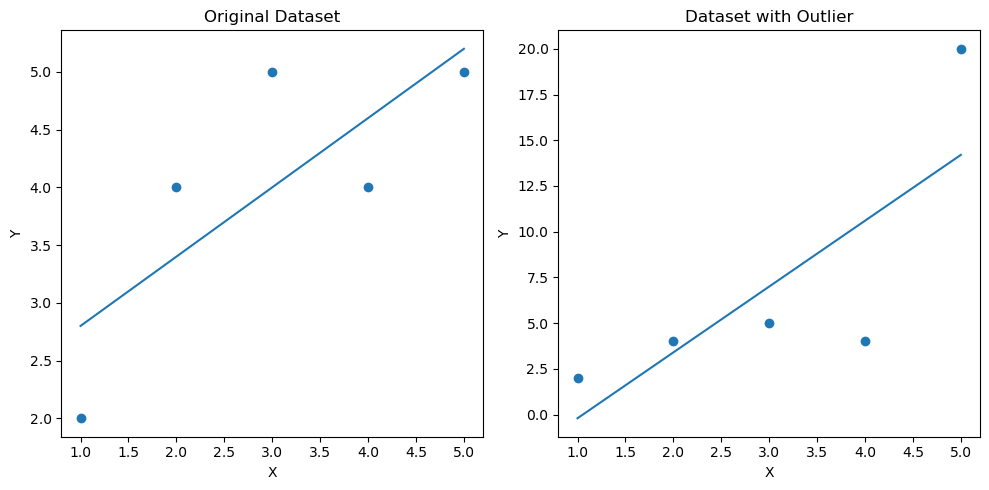

In [35]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

Y_pred_original = predict(X, b0_original, b1_original)

plt.scatter(X, Y_original)

plt.plot(X, Y_pred_original)

plt.title("Original Dataset")

plt.xlabel("X")

plt.ylabel("Y")

plt.subplot(1, 2, 2)

Y_pred_outlier = predict(X, b0_outlier, b1_outlier)

plt.scatter(X, Y_outlier)

plt.plot(X, Y_pred_outlier)

plt.title("Dataset with Outlier")

plt.xlabel("X")

plt.ylabel("Y")

plt.tight_layout()

plt.show()